In [2]:
import pandas as pd
import numpy as np
import warnings

import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, log_loss
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import make_pipeline, Pipeline
import optuna

import matplotlib.pyplot as plt
import seaborn as sns


warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

%matplotlib inline

In [3]:
train = pd.read_csv('/kaggle/input/kaggle-community-olympiad-customer-deflection/train.csv',index_col = 'Id')
test = pd.read_csv('/kaggle/input/kaggle-community-olympiad-customer-deflection/test.csv',index_col = 'Id')

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 404165 entries, 186878 to 345496
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Age                404165 non-null  float64
 1   Gender             404165 non-null  object 
 2   Tenure             404165 non-null  float64
 3   Usage Frequency    404165 non-null  float64
 4   Support Calls      404165 non-null  float64
 5   Payment Delay      404165 non-null  float64
 6   Subscription Type  404165 non-null  object 
 7   Contract Length    404165 non-null  object 
 8   Total Spend        404165 non-null  float64
 9   Last Interaction   404165 non-null  float64
 10  Churn              404165 non-null  float64
dtypes: float64(8), object(3)
memory usage: 37.0+ MB


In [5]:
train.describe()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,404165.000000,404165.000000,404165.000000,404165.000000,404165.000000,404165.000000,404165.000000,404165.000000
mean,39.709388,31.346693,15.718976,3.830703,13.494808,620.278390,14.603890,0.554776
std,12.681057,17.231919,8.617287,3.134619,8.453428,245.179751,8.609196,0.496991
min,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,29.000000,16.000000,8.000000,1.000000,6.000000,446.670000,7.000000,0.000000
50%,40.000000,32.000000,16.000000,3.000000,13.000000,649.000000,14.000000,1.000000
75%,49.000000,46.000000,23.000000,6.000000,20.000000,824.000000,22.000000,1.000000
max,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [6]:
train.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
Id,,,,,,,,,,,
186878,23.0,Male,44.0,18.0,0.0,19.0,Basic,Quarterly,846.18,18.0,0.0
414188,19.0,Male,41.0,29.0,1.0,26.0,Basic,Annual,149.04,10.0,1.0
419671,40.0,Male,48.0,11.0,3.0,19.0,Basic,Annual,266.00,9.0,1.0
428771,44.0,Female,58.0,21.0,2.0,27.0,Standard,Quarterly,662.00,16.0,1.0
302010,49.0,Male,24.0,29.0,9.0,9.0,Standard,Monthly,857.00,8.0,1.0


In [7]:
num_cols = train.select_dtypes(include='number').columns.tolist()
cat_cols = train.select_dtypes(include = 'object').columns.tolist()

In [8]:
for col in cat_cols:
    print(f'\n {train[col].value_counts()}')


 Gender
Male      224329
Female    179836
Name: count, dtype: int64

 Subscription Type
Standard    136349
Premium     135993
Basic       131823
Name: count, dtype: int64

 Contract Length
Annual       158947
Quarterly    157957
Monthly       87261
Name: count, dtype: int64


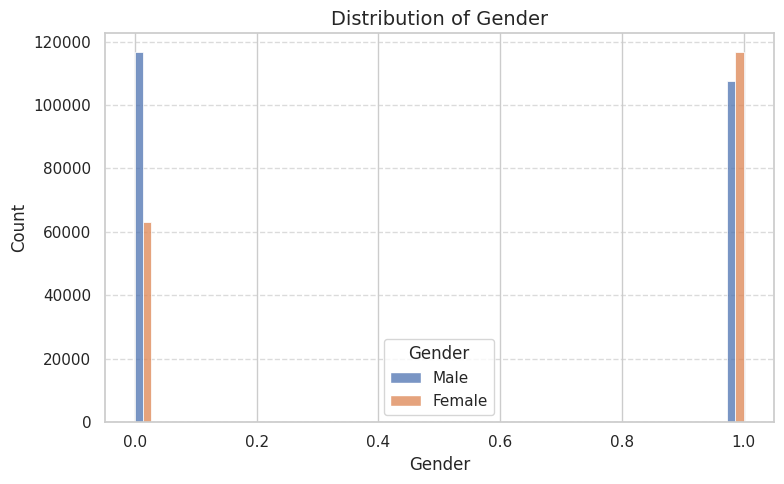

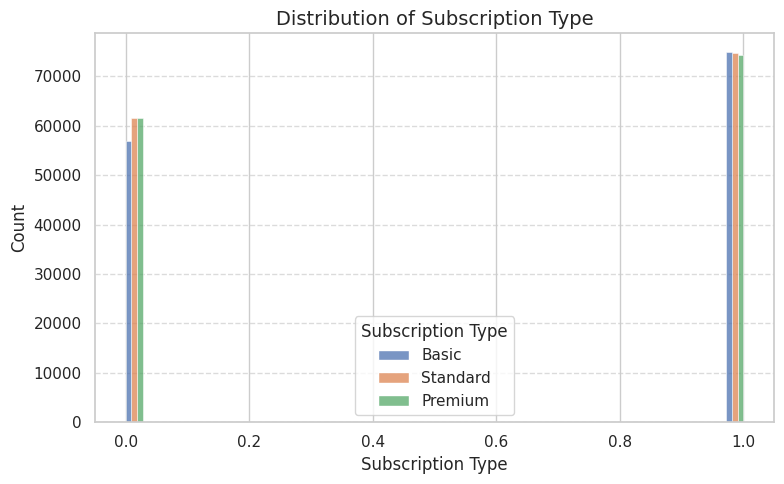

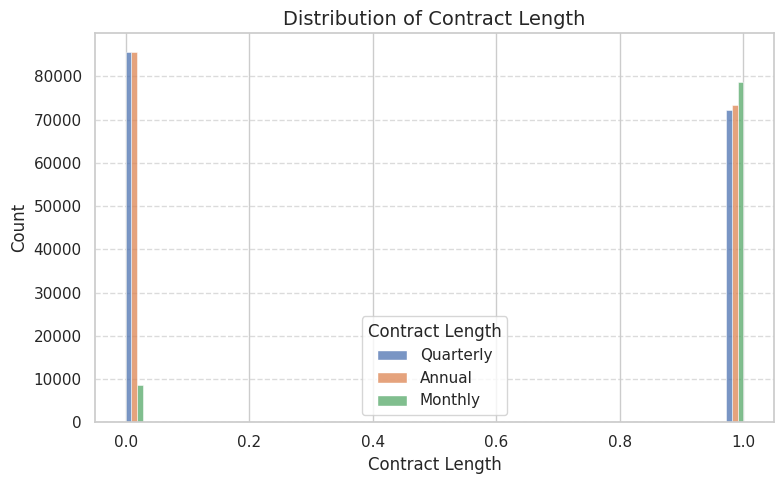

In [16]:
for col in cat_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=train,x='Churn',hue=col,multiple='dodge')
    plt.title(f'Distribution of {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

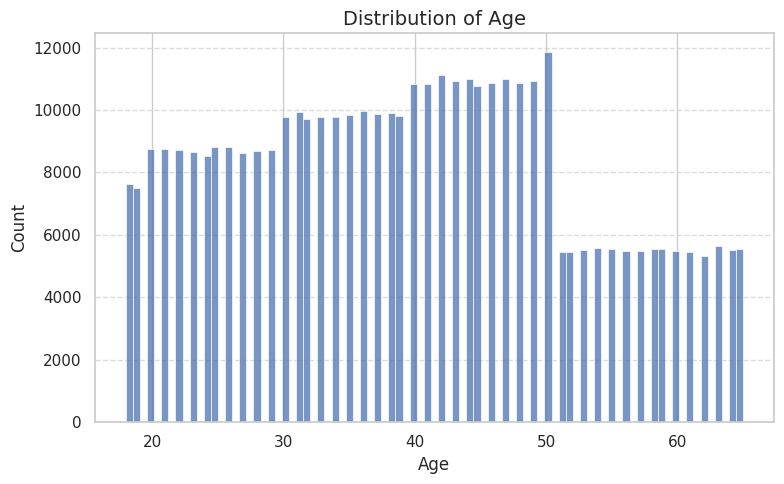

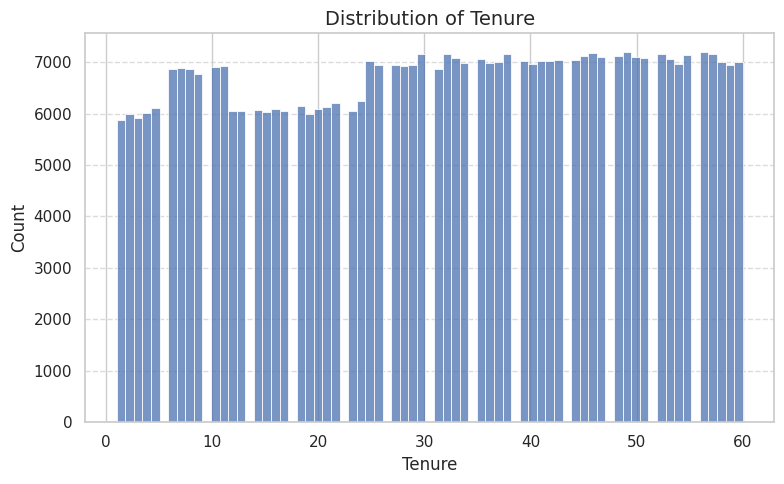

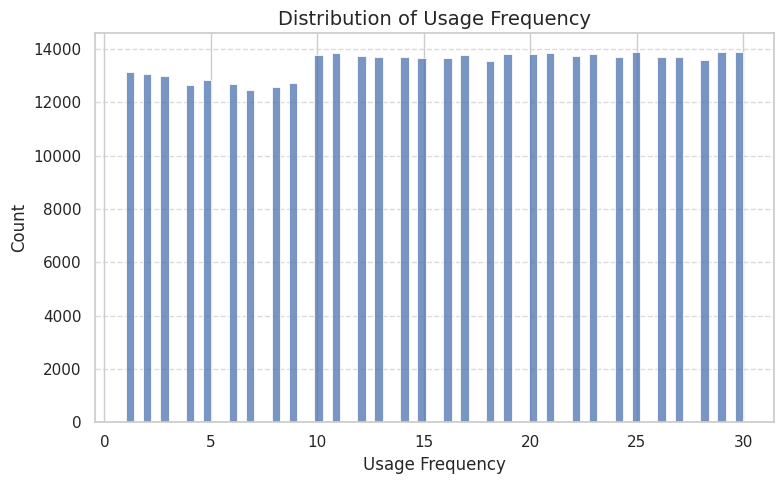

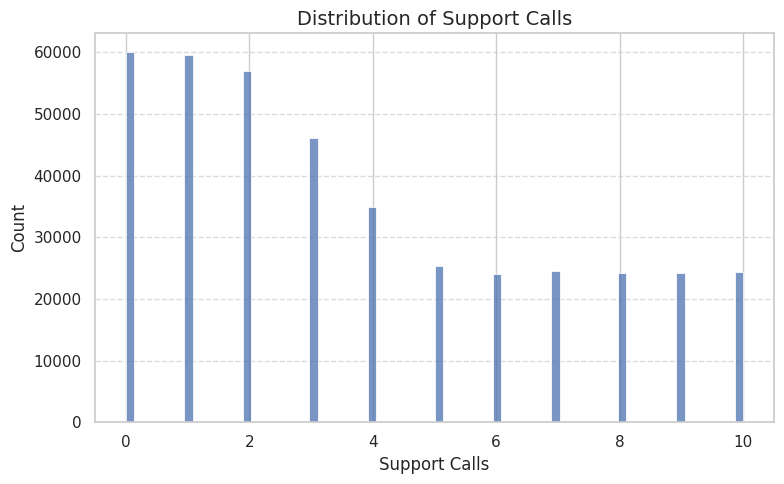

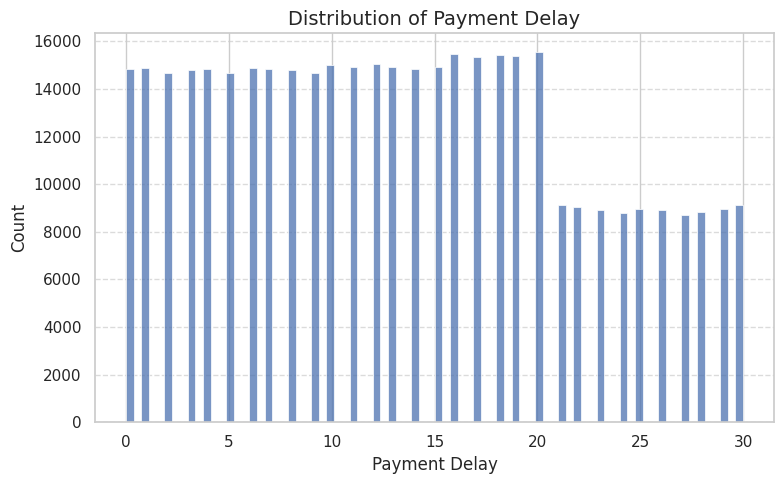

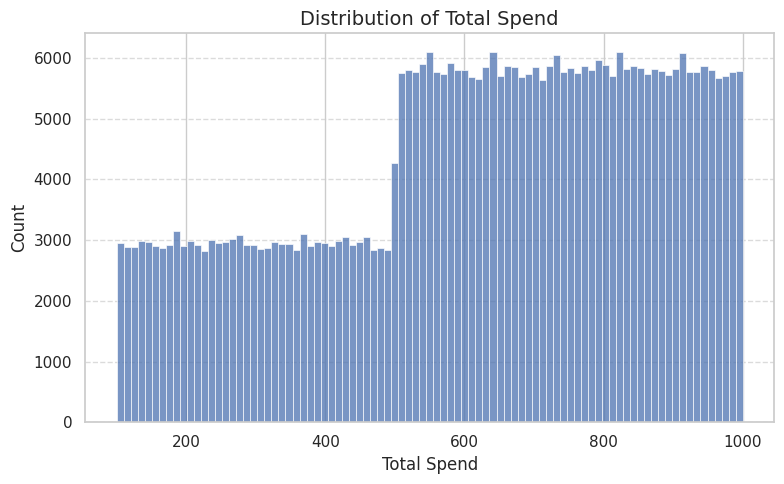

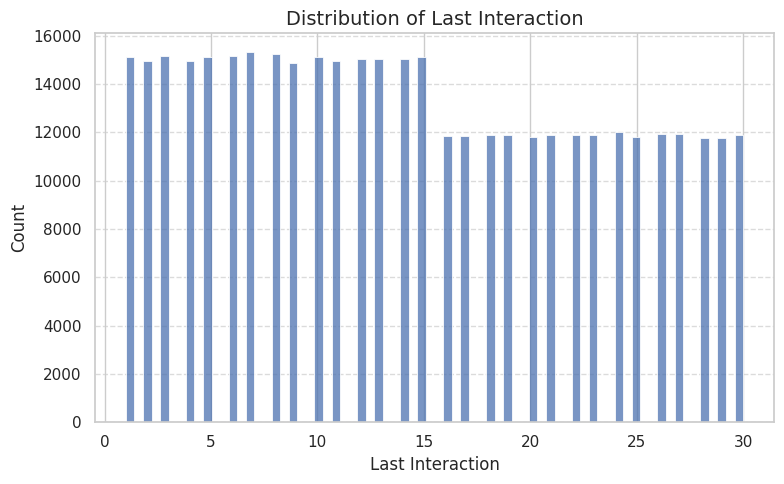

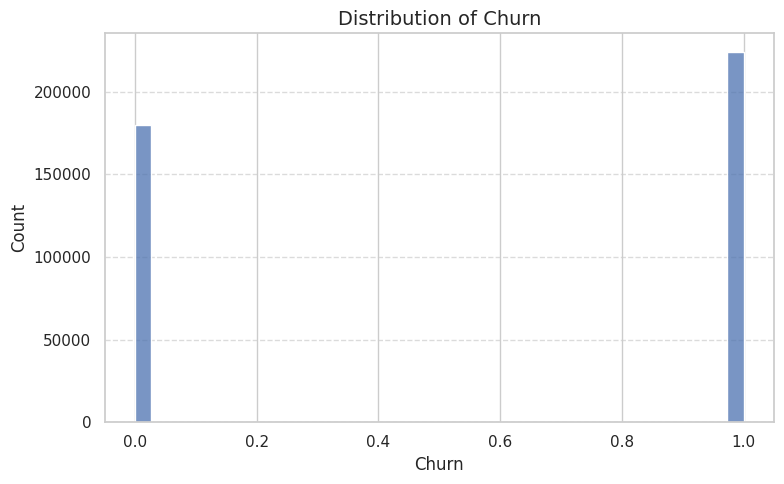

In [40]:
for col in num_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=train,x=col)
    plt.title(f'Distribution of {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

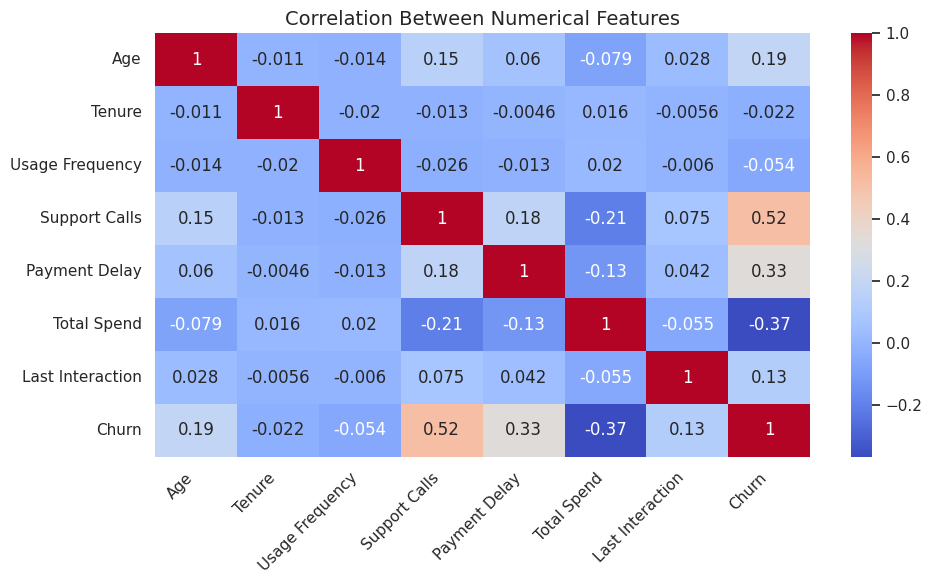

In [18]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    train[num_cols].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Between Numerical Features", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [47]:
X = train.drop('Churn', axis=1).copy()
y = train['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, shuffle=True, random_state=42)

In [48]:
def column_ratio(X):
    return X[:,[0]]/X[:,[1]]

def ratio_name(function_transformer, feature_names_in):
    return ['ratio']

def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy='median'),
        FunctionTransformer(column_ratio, feature_names_out=ratio_name),
        StandardScaler()
    )
    
cat_pipeline = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder()
)

default_num_pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

preprocessing = ColumnTransformer([
    ('tenure_per_age', ratio_pipeline(), ['Tenure','Age']),
    ('spend_per_tenure',ratio_pipeline(),['Total Spend','Tenure']),
    ('cat', cat_pipeline, make_column_selector(dtype_include=object)),
    ('num',default_num_pipeline,make_column_selector(dtype_include=np.number))
    ],
    remainder='passthrough')

model = Pipeline(steps=[
    ('preprocessor', preprocessing),
    ('scaler', StandardScaler()),
    ('classifier', XGBClassifier(objective = 'binary:logistic',eval_metric = 'logloss',random_state=42))
])

In [49]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('tenure_per_age',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x7d123c0b4040>,
                                                                                       func=<function column_ratio at 0x7d123c007380>)),
                                                                  ('standardscaler',
                                                                   StandardScaler(...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, random_state=42, ...))])

In [50]:
test_pred = model.predict_proba(X_test)[:,1]
test_labels = (test_pred > 0.5).astype(int)
accuracy = accuracy_score(y_test, test_labels)
roc_auc = roc_auc_score(y_test, test_pred)
logloss = log_loss(y_test, test_pred)
print(f'Accuracy: {accuracy}')
print(f'ROC AUC Score: {roc_auc}')
print(f'Log Loss: {logloss}')
print(classification_report(y_test, test_labels))

Accuracy: 0.9341110684992515
ROC AUC Score: 0.9539488518499146
Log Loss: 0.19336454467471287
              precision    recall  f1-score   support

         0.0       0.99      0.86      0.92     35976
         1.0       0.90      0.99      0.94     44857

    accuracy                           0.93     80833
   macro avg       0.94      0.93      0.93     80833
weighted avg       0.94      0.93      0.93     80833



In [51]:
feature_importances = model['classifier'].feature_importances_
sorted( zip(feature_importances,model['preprocessor'].get_feature_names_out()),reverse=True)

[(0.31824055, 'num__Support Calls'),
 (0.30902404, 'cat__Contract Length_Monthly'),
 (0.121260405, 'num__Total Spend'),
 (0.07218547, 'num__Payment Delay'),
 (0.06169815, 'num__Age'),
 (0.044179104, 'cat__Gender_Female'),
 (0.029024733, 'num__Last Interaction'),
 (0.014420608, 'num__Tenure'),
 (0.0066600526, 'cat__Subscription Type_Basic'),
 (0.005285155, 'num__Usage Frequency'),
 (0.0036667432, 'tenure_per_age__ratio'),
 (0.0036506222, 'cat__Contract Length_Annual'),
 (0.002881132, 'cat__Subscription Type_Premium'),
 (0.002693528, 'spend_per_tenure__ratio'),
 (0.002588193, 'cat__Subscription Type_Standard'),
 (0.0025415327, 'cat__Contract Length_Quarterly'),
 (0.0, 'cat__Gender_Male')]

In [53]:
def objective(trial):
    params = {
        'classifier__n_estimators': trial.suggest_int('n_estimators', 300, 700),
        'classifier__learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'classifier__max_depth': trial.suggest_int('max_depth', 6, 10),
        'classifier__subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'classifier__colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0)
    }
    
    model = Pipeline([
        ('preprocessor', preprocessing),
        ('scaler', StandardScaler()),
        ('classifier', XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42))
    ])
    
    model.set_params(**params)
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring='neg_log_loss')
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print("Best trial params:", study.best_trial.params)

best_xgb = Pipeline([
    ('preprocessor', preprocessing),
    ('scaler', StandardScaler()),
    ('classifier', XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42))
])
best_params = {f'classifier__{k}': v for k, v in study.best_trial.params.items()}
best_xgb.set_params(**best_params)
best_xgb.fit(X_train, y_train)


[I 2025-08-28 00:08:41,437] A new study created in memory with name: no-name-25213cea-66fa-4fa8-a8cd-2339008462fc
[I 2025-08-28 00:09:19,034] Trial 0 finished with value: -0.2075193351748077 and parameters: {'n_estimators': 461, 'learning_rate': 0.08646426485561873, 'max_depth': 10, 'subsample': 0.7120033630545098, 'colsample_bytree': 0.8655042510574777}. Best is trial 0 with value: -0.2075193351748077.
[I 2025-08-28 00:09:38,120] Trial 1 finished with value: -0.19731970656253137 and parameters: {'n_estimators': 242, 'learning_rate': 0.04889870510381289, 'max_depth': 9, 'subsample': 0.6617837143604608, 'colsample_bytree': 0.6461018136702649}. Best is trial 1 with value: -0.19731970656253137.
[I 2025-08-28 00:10:00,022] Trial 2 finished with value: -0.20933776459871686 and parameters: {'n_estimators': 312, 'learning_rate': 0.1699212999610974, 'max_depth': 9, 'subsample': 0.8757606612180762, 'colsample_bytree': 0.7173029936272279}. Best is trial 1 with value: -0.19731970656253137.
[I 202

Best trial params: {'n_estimators': 518, 'learning_rate': 0.012887768900267728, 'max_depth': 10, 'subsample': 0.8519927977723808, 'colsample_bytree': 0.9623688597706129}


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('tenure_per_age',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x7d123c0b4040>,
                                                                                       func=<function column_ratio at 0x7d123c007380>)),
                                                                  ('standardscaler',
                                                                   StandardScaler(...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None,
                               learning_rate=0.012887768900267728, max_bin=None,
                               max_cat_threshold=None, max_cat_to_onehot=None,
                               max_delta_step=None, max_depth=10,
                               max_leaves=None, min_child_weight=None,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=518,
                               n_jobs=None, num_parallel_tree=None,
                               random_state=42, ...))])

In [54]:
test_pred = best_xgb.predict_proba(X_test)[:,1]
test_labels = (test_pred > 0.5).astype(int)
accuracy = accuracy_score(y_test, test_labels)
roc_auc = roc_auc_score(y_test, test_pred)
logloss = log_loss(y_test, test_pred)
print(f'Accuracy: {accuracy}')
print(f'ROC AUC Score: {roc_auc}')
print(f'Log Loss: {logloss}')
print(classification_report(y_test, test_labels))

Accuracy: 0.93621416995534
ROC AUC Score: 0.9539877379915397
Log Loss: 0.18482916576162137
              precision    recall  f1-score   support

         0.0       1.00      0.86      0.92     35976
         1.0       0.90      1.00      0.95     44857

    accuracy                           0.94     80833
   macro avg       0.95      0.93      0.93     80833
weighted avg       0.94      0.94      0.94     80833



In [55]:
feature_importances = best_xgb['classifier'].feature_importances_
sorted( zip(feature_importances,best_xgb['preprocessor'].get_feature_names_out()),reverse=True)

[(0.2899517, 'num__Support Calls'),
 (0.2713095, 'cat__Contract Length_Monthly'),
 (0.07648039, 'cat__Gender_Female'),
 (0.072789736, 'cat__Gender_Male'),
 (0.072089046, 'num__Total Spend'),
 (0.06689243, 'num__Payment Delay'),
 (0.051102336, 'num__Age'),
 (0.020363064, 'cat__Contract Length_Quarterly'),
 (0.018524187, 'num__Tenure'),
 (0.014769143, 'cat__Contract Length_Annual'),
 (0.012300605, 'cat__Subscription Type_Basic'),
 (0.011908607, 'num__Last Interaction'),
 (0.0055155153, 'num__Usage Frequency'),
 (0.004548356, 'spend_per_tenure__ratio'),
 (0.0044434904, 'tenure_per_age__ratio'),
 (0.0035685506, 'cat__Subscription Type_Premium'),
 (0.0034433233, 'cat__Subscription Type_Standard')]

In [57]:
submission = pd.read_csv('/kaggle/input/kaggle-community-olympiad-customer-deflection/test.csv')
submission['Churn'] = best_xgb.predict_proba(test)[:,1]
submission[['Id','Churn']].to_csv("submission.csv", index=False)